##                Exploratory Data Analysis on the
##                     Titanic Dataset
**Report**

_____________________________________________________________________________

## Introduction

The Titanic dataset documents information on the passengers aboard the RMS Titanic. This analysis aims to identify key factors that influenced passenger survival during the disaster. Through data cleaning, visualizations, and statistical insights, we explore socio-economic, demographic, and categorical attributes that may have impacted survival outcomes.

**Dataset Overview:**

- Rows: 892

- Columns: 12

**Key features:**

  - PassengerId:  A unique identifier for each passenger

  - Survived: Indicates whether the passenger survived (1) or did not survive (0).

  - Pclass: Passenger class (1st, 2nd, or 3rd), a proxy for socio-economic status.

  - Name: The name of the passenger.

  - Sex: The gender of the passenger (male or female).

  - Age: The age of the passenger in years.

  - SibSp: the number of siblings or spouses a passenger had on board the Titanic.

  - Parch: The number of parents/children the passenger had on board.

  - Ticket: The ticket number.

  - Fare: The fare the passenger paid.
  
  - Cabin: The cabin number.

  - Embarked: The port where the passenger embarked (C = Cherbourg, Q = Queenstown, S = Southampton).

--------------------------------------------
## Data Cleaning

**IMPORT MODULES**

In [19]:
import pandas as pd
import numpy as np
import io 
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, RobustScaler

**LOAD DATASET**

In [20]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Display the first 5 rows of Wine.csv
df = pd.read_csv("Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**DATASET OVERVIEW AND PREPROCESSING**

BASIC INFORMATION OF TITANIC DATASET

In [21]:
# Display basic info
buffer = io.StringIO()
df.info(buf=buffer)
info_string = buffer.getvalue()

# Simple parsing to get column info (more robust parsing might be needed for complex cases)
lines = info_string.splitlines()
column_info_lines = [line for line in lines if 'non-null' in line]

column_data = []
for line in column_info_lines:
    parts = line.split()
    column_name = parts[1]
    non_null_count = int(parts[2])
    dtype = parts[-1]
    column_data.append({'Column': column_name, 'Non-Null Count': non_null_count, 'Dtype': dtype})

info_df = pd.DataFrame(column_data)
print(info_df)

         Column  Non-Null Count    Dtype
0   PassengerId             891    int64
1      Survived             891    int64
2        Pclass             891    int64
3          Name             891   object
4           Sex             891   object
5           Age             714  float64
6         SibSp             891    int64
7         Parch             891    int64
8        Ticket             891   object
9          Fare             891  float64
10        Cabin             204   object
11     Embarked             889   object


MISSING VALUES INSIDE TITANIC DATASET

In [22]:
# Check for missing values
missing_values = df.isnull().sum()
print()
print("Missing Value Count: ")
print(missing_values)



Missing Value Count: 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**Visualizing Missing Data**

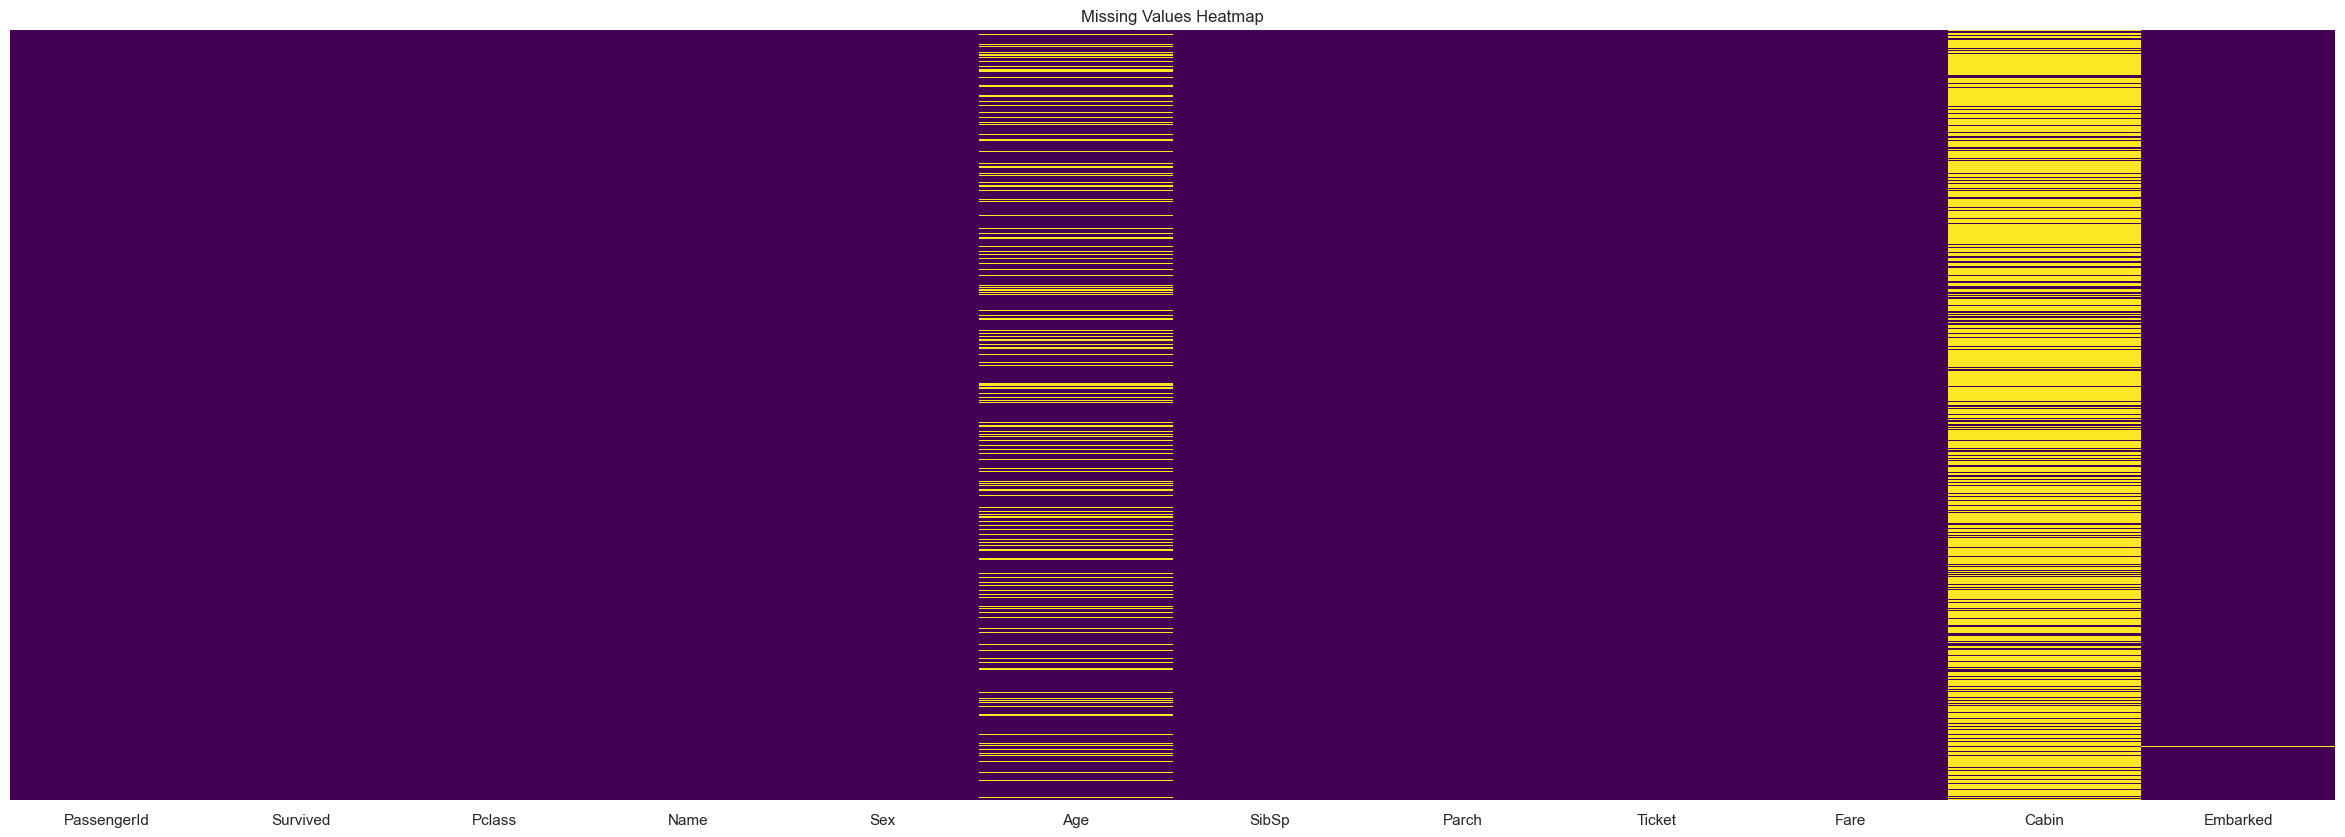

In [23]:
# Visualise missing values using seaborn heatmap
plt.figure(figsize=(30, 10))  # Set the figure size
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")  # Add a title to the plot
plt.show()

DESCRIPTIVE STATISTICS

In [24]:
# Display descriptive statistics using pd.describe()
description_df = df.describe(include='all')
print("Descriptive Statistics")
print(description_df)

Descriptive Statistics
        PassengerId    Survived      Pclass                     Name   Sex  \
count    891.000000  891.000000  891.000000                      891   891   
unique          NaN         NaN         NaN                      891     2   
top             NaN         NaN         NaN  Braund, Mr. Owen Harris  male   
freq            NaN         NaN         NaN                        1   577   
mean     446.000000    0.383838    2.308642                      NaN   NaN   
std      257.353842    0.486592    0.836071                      NaN   NaN   
min        1.000000    0.000000    1.000000                      NaN   NaN   
25%      223.500000    0.000000    2.000000                      NaN   NaN   
50%      446.000000    0.000000    3.000000                      NaN   NaN   
75%      668.500000    1.000000    3.000000                      NaN   NaN   
max      891.000000    1.000000    3.000000                      NaN   NaN   

               Age       SibSp       Par

**FILLING IN THE MISSING VALUES**

Age - The median can be used to fill missing values in the Age column since:

- The median is robust against outliers which means it preserves the original distribution of ages without being skewed by outliers.
- It is more representative of the central tendency of the dataset.

In [25]:
df['Age'] = df['Age'].fillna(df['Age'].median())

Embarked - The mode can be used to fill the missing values in the Embarked column since:

- The data nominal and the categories are not hieratary.
- Only two values are missing, making the mode a straightforward and justifiable choice given its simplicity and the small number of imputations needed.

In [26]:
mode_point = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(mode_point)

Cabin - Due to the large amount of missing values in the Cabin column(687 out of 891), the column will be dropped.

In [27]:
df.drop(columns=['Cabin'], inplace=True)

_________________________________________________________
## Data Stories and Visualasations

In order to understand the initial distribution and relationships within the data, histograms will be lotted to see what the distribution of continuous numerical features(ie. data from Age and Fare column) is like.

HISTOGRAM FOR 'Age' AND 'Fare' 

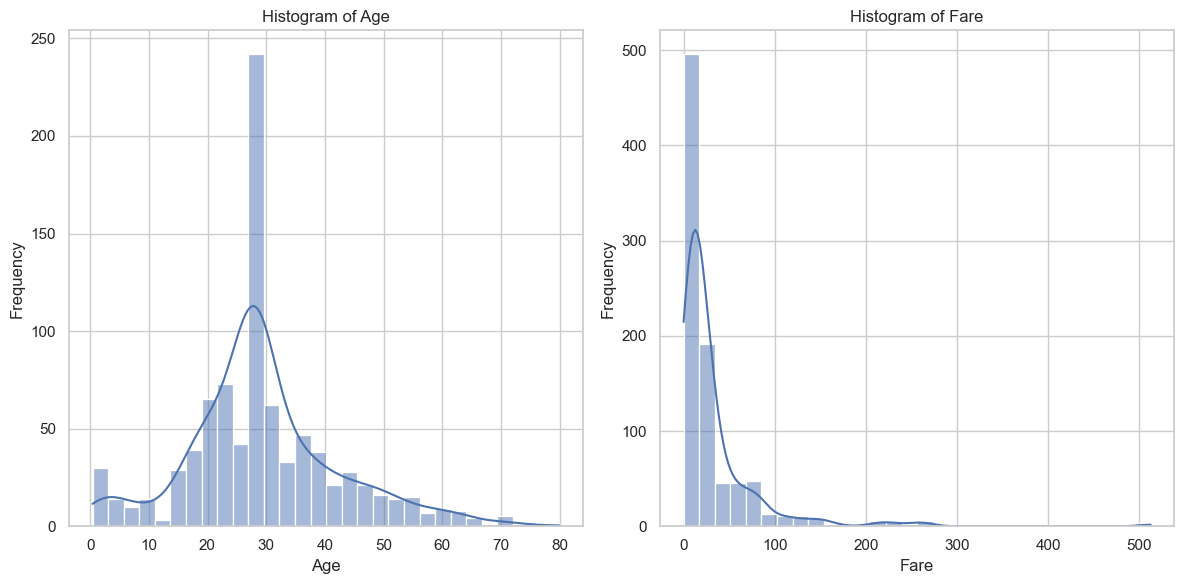

In [28]:
# Visualize the distribution of 'Age' and 'Fare' using histograms
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title('Histogram of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()



Observations:

- The 'Age' histogram shows a roughly normal distribution, with a peak around 30 years old, slightly right-skewed, indicating a few older passengers.

- The 'Fare' histogram is highly right-skewed with most values on the lower side with a few outliers stretching up to 500.

BOX PLOT FOR 'Age'AND 'Fare'

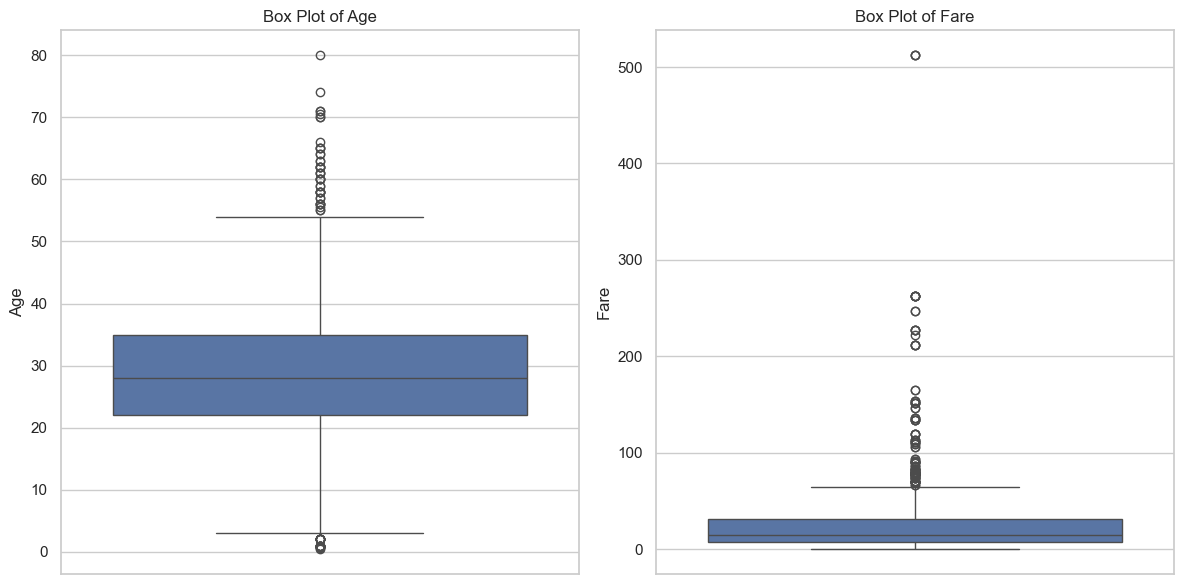

In [29]:
# Visualize the distribution of 'Age' and 'Fare' using box plots
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Fare'])
plt.title('Box Plot of Fare')
plt.ylabel('Fare')

plt.tight_layout()
plt.show()


Observations:

- The 'Age' box plot shows a median close to 30, with outliers beyond 60, indicating elder passengers.

- The 'Fare' box plot shows a low median fare with numerous outliers above 300.

COUNT PLOTS FOR 'Pclass' and 'Embarked'

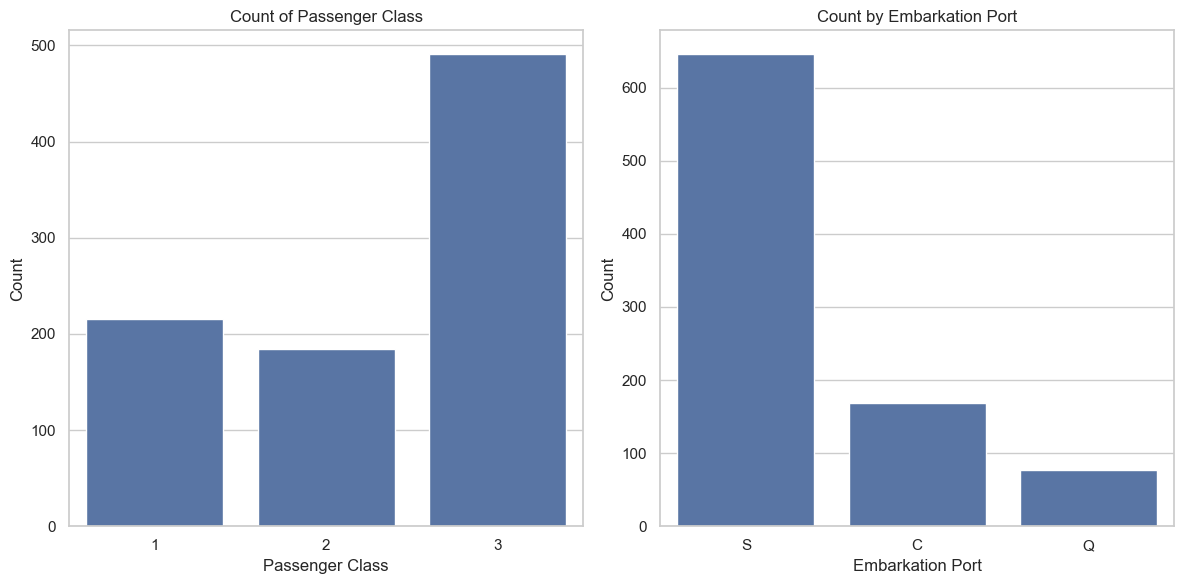

In [30]:
# Visualize the count of passengers by 'Pclass' and 'Embarked'
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.countplot(x=df['Pclass'])
plt.title('Count of Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x=df['Embarked'])
plt.title('Count by Embarkation Port')
plt.xlabel('Embarkation Port')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


Observations:

- The count plot for 'Pclass' shows most passengers were in the third class, followed by first and second class, indicating socio-economics disparities.

- The count plot for 'Embarked' shows that most passengers embarked from portS(Southampton), followed by C(Cherbourg) and Q(Queenstown). This indicates that Southampton was the most common embarkation point.

**CONVERT CATEGORICAL DATA INTO NUMERICAL VALUES FOR FURTHER ANALYSIS**

First the Sex column will be converted into numerical data by mapping the values 'male' to 0 and 'female' to 1

In [31]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

**Why?**

Machine learning and statistical models require numerical input. Encoding categorical data like Sex enables correlation and prediction analysis.

**CORRELATION ANALYSIS**

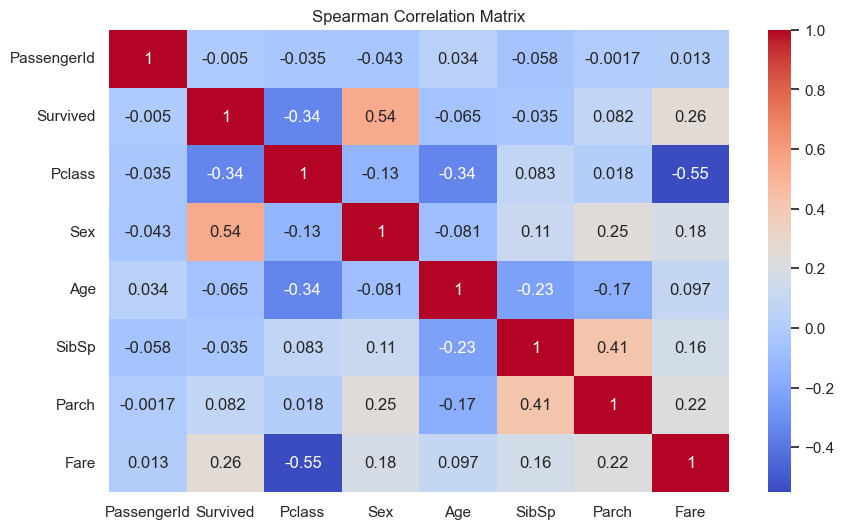

In [32]:
# ===Correlation Matrix===
# Safe version before correlation
df_corr = df.copy()

# Drop any remaining non-numeric columns
df_corr = df_corr.select_dtypes(include=[np.number])

# Correlation heatmap
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm')
plt.title("Spearman Correlation Matrix")
plt.show()


**Key Takeaways for the survival column:**

The most influenitial factors for survival are Sex, Pclass and Fare.

- Positively Correlated with Sex (0.54):
  - There is a moderate association between sex and survival. This suggests that gender played a significant role in survival rates, with women having a higher likelihood of survival compared to men.



- Negatively Correlated with Pclass(-0.34):
  - Lower class passengers (higher Pclass value) tend to have lower survival rates.  



- Positively Correlated with Fare(0.26):
  - Passengers who paid higher fares tend to have higher survival rates.




| Factor   | Correlation | Insight                                   |
| -------- | ----------- | ----------------------------------------- |
| `Sex`    | +0.54       | Women had higher survival                 |
| `Pclass` | -0.34       | Higher-class passengers survived more     |
| `Fare`   | +0.26       | More expensive tickets linked to survival |


**BAR GRAPHS FOR FURTHER ANALYSIS**

BAR GRAPHS: “Women and Children First”

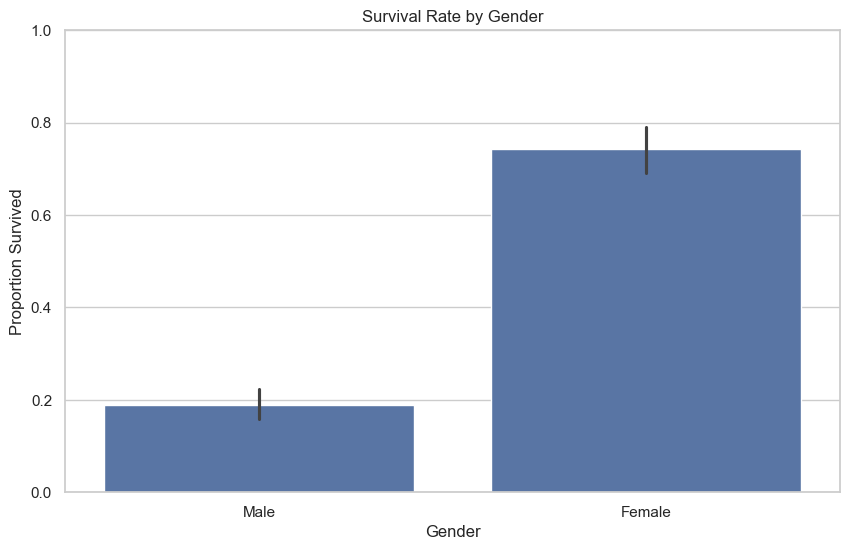

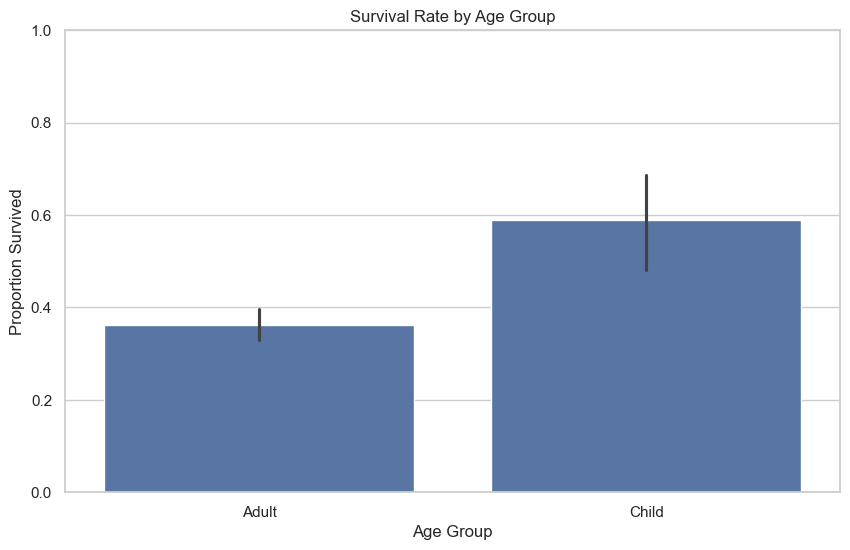

In [33]:
# Gender survival rate
sns.barplot(data=df, x='Sex', y='Survived')
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Proportion Survived')
plt.xticks([0, 1], ['Male', 'Female'])
plt.ylim(0, 1)
plt.show()


# Children survival
df['Is_child'] = df['Age'] < 16
sns.barplot(data=df, x='Is_child', y='Survived')
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion Survived')
plt.xticks([0, 1], ['Adult', 'Child'])
plt.ylim(0, 1)
plt.show()


Observation:

- According to the bar graph of survival rate between man and woman, women had a higher survival rate.

- According to the bar graph of survival rate between adult and child, children had a higher survival rate.

-  Women and children had significantly higher survival rates in both bar grapgs, confirming the “Women and children first” rule.

BAR GRAPH: Class-Based Preference

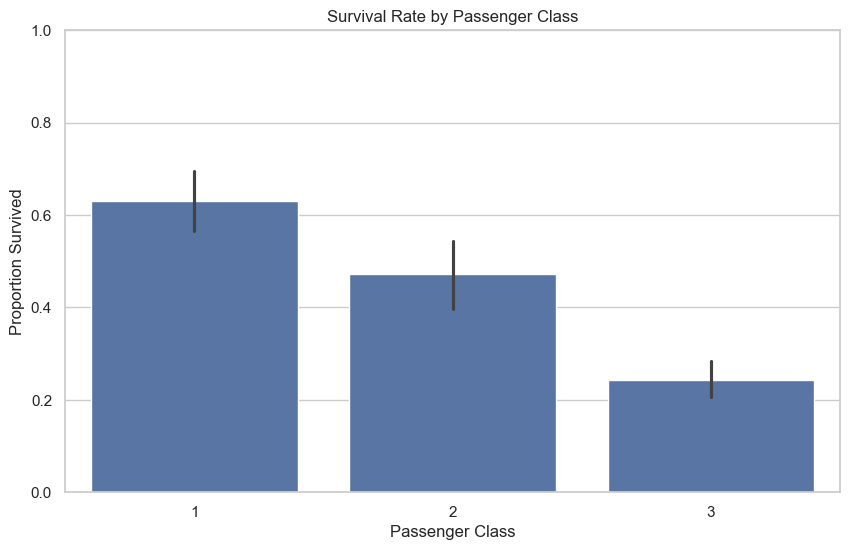

In [34]:
# Survival rate by passenger class
sns.barplot(data=df, x='Pclass', y='Survived')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Proportion Survived')
plt.ylim(0, 1)
plt.show()


Observation:

- According to the bar graph, , the 1st class passengers had a much higher survival rate, supporting the idea that upper-class passengers were given preference on lifeboats.

GROUPED BAR GRAPH: Survival by Class and Gender

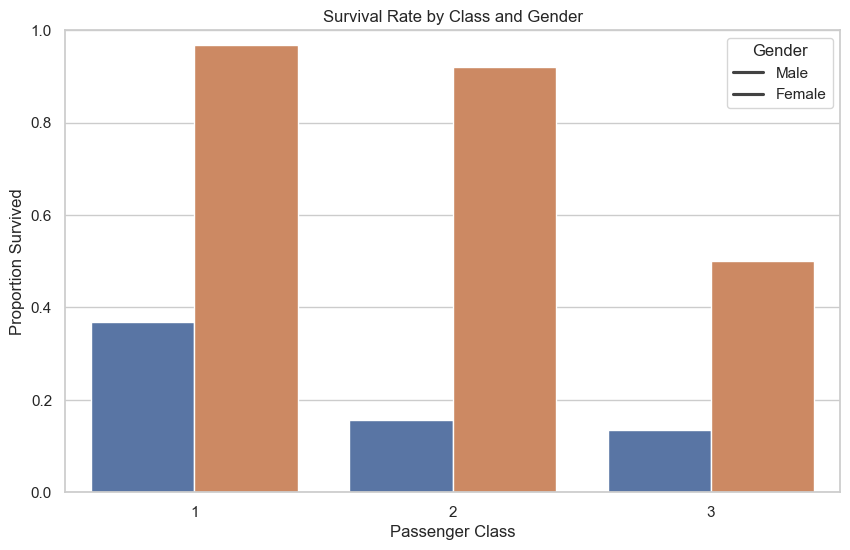

In [35]:
# Survival rate by class and gender
summary = df.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()
sns.barplot(data=summary, x='Pclass', y='Survived', hue='Sex')
plt.title('Survival Rate by Class and Gender')
plt.xlabel('Passenger Class')
plt.ylabel('Proportion Survived')
plt.ylim(0, 1)
plt.legend(title='Gender', labels=['Male', 'Female'])
plt.show()


Observations:
 - According to the grouped bar graph and the pivot table:

 
   - Women in first-class  and second-class had significant higher survival rates, supporting the idea that women that were in upper-class had preference on lifeboats 

   - Women in low-class or third-class still had a higher survival rate than the men, despite having lower survival rates than the upper-class women.



BAR GRAPH: Survival by Embarkation Port

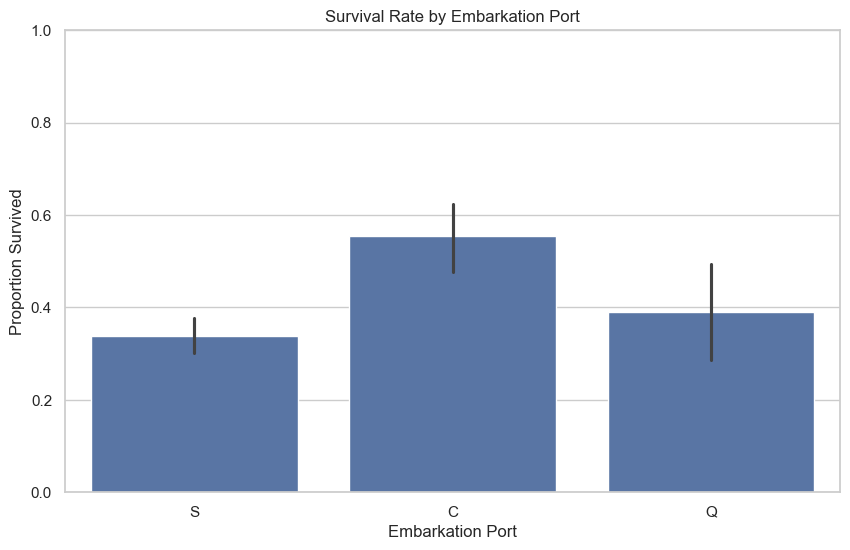

In [36]:
# Survival rate by embarkation port
sns.barplot(data=df, x='Embarked', y='Survived')
plt.title('Survival Rate by Embarkation Port')
plt.xlabel('Embarkation Port')
plt.ylabel('Proportion Survived')
plt.ylim(0, 1)
plt.show()


Observation:

- According to the bar graph, passengers who embarked from Cherbourg ('C') had a noticeably higher survival rate.

## Summary of Findings

| Topic                    | Summary                             |
| ------------------------ | ----------------------------------- |
| **Key Survival Factors** | `Sex`, `Pclass`, and `Fare`         |
| **Women and Children**   | Substantially higher survival rates |
| **Class Preference**     | 1st class passengers prioritized    |
| **Upper-Class Women**    | Highest overall survival            |
| **Embarkation Impact**   | Cherbourg passengers fared best     |
